In [125]:
import os
import copy
import time
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch :", torch.__version__)
print("Device  :", device)

PyTorch : 2.11.0+cu130
Device  : cuda


In [126]:
!rm -rf repo dataset
!git clone -q https://github.com/natasyahratu/Computer-Vision-and-Deep-Learning.git repo
!mkdir dataset
!unzip -q repo/dataset_patrol.zip -d dataset

data_path = "dataset/dataset_patrol"

print("oks deh")

oks deh


In [127]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

tf_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

tf_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_dataset = ImageFolder(f"{data_path}/Train", tf_train)
val_dataset = ImageFolder(f"{data_path}/Val", tf_test)
test_dataset = ImageFolder(f"{data_path}/Test", tf_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Kelas :", train_dataset.classes)
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Kelas : ['car', 'motorcycle']
Train : 160
Val   : 20
Test  : 20


In [128]:
def buat_model():
    model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(device)

print("ResNet50 siap")

ResNet50 siap


In [129]:
def train(mode, epochs=10):
    model = buat_model()

    if mode == "feature":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
        lr = 0.001

    elif mode == "partial":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
        lr = 0.0001

    else:
        for p in model.parameters():
            p.requires_grad = True
        lr = 0.00001

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct = total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            correct += (output.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_acc.append(correct / total)

        model.eval()
        correct = total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                output = model(images.to(device))
                correct += (output.argmax(1).cpu() == labels).sum().item()
                total += labels.size(0)

        val_acc.append(correct / total)

        print(
            f"{mode} | Epoch {epoch+1}/{epochs} | "
            f"Train: {train_acc[-1]:.3f} | Val: {val_acc[-1]:.3f}"
        )

    return {
        "mode": mode,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "model": model
    }

In [130]:
hasil_mode1 = train("feature")

feature | Epoch 1/10 | Train: 0.750 | Val: 1.000
feature | Epoch 2/10 | Train: 0.975 | Val: 1.000
feature | Epoch 3/10 | Train: 0.994 | Val: 0.900
feature | Epoch 4/10 | Train: 0.975 | Val: 0.900
feature | Epoch 5/10 | Train: 0.994 | Val: 0.950
feature | Epoch 6/10 | Train: 0.988 | Val: 0.950
feature | Epoch 7/10 | Train: 0.994 | Val: 0.950
feature | Epoch 8/10 | Train: 0.994 | Val: 0.950
feature | Epoch 9/10 | Train: 0.988 | Val: 0.950
feature | Epoch 10/10 | Train: 1.000 | Val: 0.950


In [131]:
hasil_mode2 = train("partial")

partial | Epoch 1/10 | Train: 0.794 | Val: 1.000
partial | Epoch 2/10 | Train: 1.000 | Val: 1.000
partial | Epoch 3/10 | Train: 0.994 | Val: 1.000
partial | Epoch 4/10 | Train: 1.000 | Val: 1.000
partial | Epoch 5/10 | Train: 1.000 | Val: 0.950
partial | Epoch 6/10 | Train: 0.994 | Val: 0.950
partial | Epoch 7/10 | Train: 1.000 | Val: 0.900
partial | Epoch 8/10 | Train: 0.994 | Val: 0.900
partial | Epoch 9/10 | Train: 1.000 | Val: 0.900
partial | Epoch 10/10 | Train: 1.000 | Val: 0.950


In [132]:
hasil_mode3 = train("full")

full | Epoch 1/10 | Train: 0.588 | Val: 0.800
full | Epoch 2/10 | Train: 0.775 | Val: 0.750
full | Epoch 3/10 | Train: 0.856 | Val: 0.900
full | Epoch 4/10 | Train: 0.925 | Val: 0.950
full | Epoch 5/10 | Train: 0.963 | Val: 0.950
full | Epoch 6/10 | Train: 0.981 | Val: 0.950
full | Epoch 7/10 | Train: 0.988 | Val: 0.950
full | Epoch 8/10 | Train: 0.975 | Val: 0.950
full | Epoch 9/10 | Train: 0.994 | Val: 0.950
full | Epoch 10/10 | Train: 0.994 | Val: 0.950


In [133]:
def evaluasi(model):
    model.eval()
    y_true, y_pred = [], []

    start = time.time()

    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images.to(device))
            y_true.extend(labels.numpy())
            y_pred.extend(output.argmax(1).cpu().numpy())

    if device.type == "cuda":
        torch.cuda.synchronize()

    latency = (time.time() - start) / len(test_dataset) * 1000

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1": f1_score(y_true, y_pred, average="weighted"),
        "Latency (ms/image)": latency
    }


hasil_evaluasi = pd.DataFrame(
    [
        evaluasi(hasil_mode1["model"]),
        evaluasi(hasil_mode2["model"]),
        evaluasi(hasil_mode3["model"])
    ],
    index=[
        "Feature Extraction",
        "Partial Fine-Tuning",
        "Full Fine-Tuning"
    ]
)

display(hasil_evaluasi.round(3))

,Accuracy,Precision,Recall,F1,Latency (ms/image)
Feature Extraction,0.85,0.885,0.85,0.847,44.721
Partial Fine-Tuning,0.90,0.917,0.90,0.899,45.792
Full Fine-Tuning,0.95,0.955,0.95,0.950,50.431


In [134]:
for h in [hasil_mode1, hasil_mode2, hasil_mode3]:
    print(h["mode"])
    print(h["val_acc"])

feature
[1.0, 1.0, 0.9, 0.9, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]
partial
[1.0, 1.0, 1.0, 1.0, 0.95, 0.95, 0.9, 0.9, 0.9, 0.95]
full
[0.8, 0.75, 0.9, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


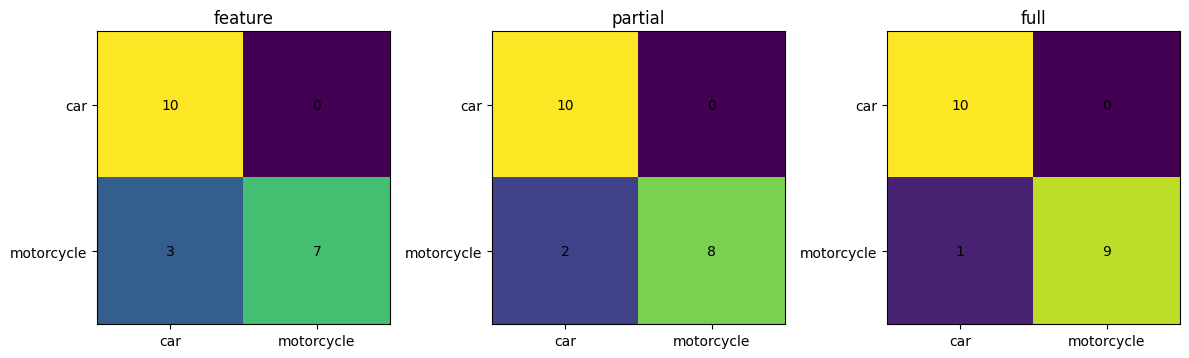

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, h in zip(axes, [hasil_mode1, hasil_mode2, hasil_mode3]):
    model = h["model"]
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            y_true += y.tolist()
            y_pred += model(x.to(device)).argmax(1).cpu().tolist()

    cm = confusion_matrix(y_true, y_pred)

    ax.imshow(cm)
    ax.set_title(h["mode"])
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(test_dataset.classes)
    ax.set_yticklabels(test_dataset.classes)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

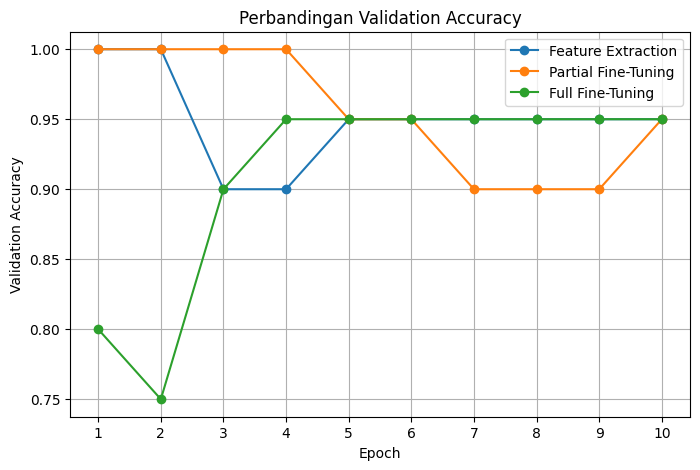

In [136]:
epochs = range(1, 11)

plt.figure(figsize=(8, 5))

plt.plot(epochs, hasil_mode1["val_acc"], marker="o",
         label="Feature Extraction")

plt.plot(epochs, hasil_mode2["val_acc"], marker="o",
         label="Partial Fine-Tuning")

plt.plot(epochs, hasil_mode3["val_acc"], marker="o",
         label="Full Fine-Tuning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.show()